# Sistem Fuzzy untuk Penilaian Resiko Kredit

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Fungsi keanggotaan trapesium
def trapezoid(x, a, b, c, d):
    if x <= a or x >= d:
        return 0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x < c:
        return 1
    elif c <= x < d:
        return (d - x) / (d - c)

# Fungsi keanggotaan segitiga
def triangle(x, a, b, c):
    if x <= a or x >= c:
        return 0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x < c:
        return (c - x) / (c - b)

In [3]:
# Membaca data, skip row pertama yang berisi header teks
data = pd.read_excel('resiko kredit.xlsx', skiprows=1, names=['No', 'Gaji (juta)', 'Tanggungan'])

In [4]:
# Memproses setiap data nasabah
hasil = []

for _, row in data.iterrows():
    # Fuzzifikasi Input
    gaji = row['Gaji (juta)']
    tanggungan = row['Tanggungan']  # Persentase cicilan (40-60%)
    
    # Himpunan fuzzy Gaji (dalam juta rupiah)
    gaji_rendah = trapezoid(gaji, 0, 0, 2, 4)
    gaji_sedang = triangle(gaji, 2, 5, 8)
    gaji_tinggi = trapezoid(gaji, 6, 8, 10, 10)
    
    # Himpunan fuzzy Tanggungan (persentase cicilan terhadap gaji)
    tanggungan_sedikit = trapezoid(tanggungan, 0, 0, 40, 48)  # < 48%
    tanggungan_sedang = triangle(tanggungan, 45, 50, 55)     # 45-55%
    tanggungan_banyak = trapezoid(tanggungan, 52, 58, 100, 100)  # > 52%
    
    # Aturan Fuzzy
    aturan1 = min(gaji_rendah, tanggungan_banyak)  # Resiko Tinggi
    aturan2 = min(gaji_rendah, tanggungan_sedang)  # Resiko Tinggi
    aturan3 = min(gaji_rendah, tanggungan_sedikit)  # Resiko Sedang
    aturan4 = min(gaji_sedang, tanggungan_banyak)  # Resiko Sedang
    aturan5 = min(gaji_sedang, tanggungan_sedang)  # Resiko Sedang
    aturan6 = min(gaji_sedang, tanggungan_sedikit)  # Resiko Rendah
    aturan7 = min(gaji_tinggi, tanggungan_banyak)  # Resiko Rendah
    aturan8 = min(gaji_tinggi, tanggungan_sedang)  # Resiko Rendah
    aturan9 = min(gaji_tinggi, tanggungan_sedikit)  # Resiko Rendah
    
    # Agregasi Output
    resiko_tinggi = max(aturan1, aturan2)
    resiko_sedang = max(aturan3, aturan4, aturan5)
    resiko_rendah = max(aturan6, aturan7, aturan8, aturan9)
    
    # Defuzzifikasi (Centroid Method)
    x_tinggi = 80  # Representasi Resiko Tinggi
    x_sedang = 50  # Representasi Resiko Sedang
    x_rendah = 20  # Representasi Resiko Rendah
    
    numerator = (resiko_tinggi * x_tinggi) + (resiko_sedang * x_sedang) + (resiko_rendah * x_rendah)
    denominator = resiko_tinggi + resiko_sedang + resiko_rendah
    
    if denominator == 0:
        resiko_crisp = 0
    else:
        resiko_crisp = numerator / denominator
    
    # Kategori Resiko
    if resiko_crisp >= 65:
        kategori = 'Tinggi'
    elif resiko_crisp >= 35:
        kategori = 'Sedang'
    else:
        kategori = 'Rendah'
    
    hasil.append({
        'Gaji (juta)': gaji,
        'Tanggungan (%)': tanggungan,
        'Resiko (Crisp)': resiko_crisp,
        'Kategori Resiko': kategori
    })

In [5]:
# Membuat DataFrame hasil
hasil_df = pd.DataFrame(hasil)
print(hasil_df)

    Gaji (juta)  Tanggungan (%)  Resiko (Crisp) Kategori Resiko
0           3.7            54.0       59.310345          Sedang
1           6.2            48.0       45.714286          Sedang
2           2.9            58.0       69.411765          Tinggi
3           9.5            44.0       20.000000          Rendah
4           4.1            52.0       50.000000          Sedang
5          11.0            37.0        0.000000          Rendah
6           5.3            46.0       33.333333          Rendah
7           7.8            41.0       20.000000          Rendah
8           3.1            56.0       66.530612          Tinggi
9          12.4            32.0        0.000000          Rendah
10          1.9            60.0       80.000000          Tinggi
11         14.8            28.0        0.000000          Rendah
12          6.9            44.0       20.000000          Rendah
13          8.5            40.0       20.000000          Rendah
14         10.2            36.0        0

In [6]:
# Export hasil ke Excel
hasil_df.to_excel('peringkat.xlsx', index=False)
print("Hasil telah disimpan ke 'peringkat.xlsx'")

Hasil telah disimpan ke 'peringkat.xlsx'


## Implementasi Metode Sugeno

In [7]:
# Coba pake sugeno buat bandingan
# Outputnya pake fungsi linear, bukan himpunan fuzzy
data_sugeno = []

for _, baris in data.iterrows():
    g = baris['Gaji (juta)']
    t = baris['Tanggungan']
    
    # fuzzifikasi sama kayak sebelumnya
    gaji_rendah = trapezoid(g, 0, 0, 2, 4)
    gaji_sedang = triangle(g, 2, 5, 8)
    gaji_tinggi = trapezoid(g, 6, 8, 10, 10)
    
    tanggungan_sedikit = trapezoid(t, 0, 0, 40, 48)
    tanggungan_sedang = triangle(t, 45, 50, 55)
    tanggungan_banyak = trapezoid(t, 52, 58, 100, 100)
    
    # aturan fuzzy tapi outputnya linear (z = ax + by + c)
    # buat resiko tinggi
    alpha1 = min(gaji_rendah, tanggungan_banyak)
    alpha2 = min(gaji_rendah, tanggungan_sedang)
    out1 = -5*g + 1.2*t + 80 if alpha1 > 0 else 0
    out2 = -5*g + 1.2*t + 80 if alpha2 > 0 else 0
    
    # resiko sedang
    alpha3 = min(gaji_rendah, tanggungan_sedikit)
    alpha4 = min(gaji_sedang, tanggungan_banyak)
    alpha5 = min(gaji_sedang, tanggungan_sedang)
    out3 = -2*g + 0.8*t + 50 if alpha3 > 0 else 0
    out4 = -2*g + 0.8*t + 50 if alpha4 > 0 else 0
    out5 = -2*g + 0.8*t + 50 if alpha5 > 0 else 0
    
    # resiko rendah
    alpha6 = min(gaji_sedang, tanggungan_sedikit)
    alpha7 = min(gaji_tinggi, tanggungan_banyak)
    alpha8 = min(gaji_tinggi, tanggungan_sedang)
    alpha9 = min(gaji_tinggi, tanggungan_sedikit)
    out6 = 1*g - 0.5*t + 20 if alpha6 > 0 else 0
    out7 = 1*g - 0.5*t + 20 if alpha7 > 0 else 0
    out8 = 1*g - 0.5*t + 20 if alpha8 > 0 else 0
    out9 = 1*g - 0.5*t + 20 if alpha9 > 0 else 0
    
    # defuzzifikasi pake weighted average
    pembilang = alpha1*out1 + alpha2*out2 + alpha3*out3 + alpha4*out4 + alpha5*out5 + alpha6*out6 + alpha7*out7 + alpha8*out8 + alpha9*out9
    penyebut = alpha1 + alpha2 + alpha3 + alpha4 + alpha5 + alpha6 + alpha7 + alpha8 + alpha9
    
    if penyebut == 0:
        nilai_resiko = 0
    else:
        nilai_resiko = pembilang / penyebut
    
    # tentuin kategorinya
    if nilai_resiko >= 65:
        kat = 'Tinggi'
    elif nilai_resiko >= 35:
        kat = 'Sedang'
    else:
        kat = 'Rendah'
    
    data_sugeno.append({
        'Gaji (juta)': g,
        'Tanggungan (%)': t,
        'Resiko Sugeno': nilai_resiko,
        'Kategori': kat
    })

In [8]:
# tampilkan hasil sugeno
df_sugeno = pd.DataFrame(data_sugeno)
print("\nHasil Metode Sugeno:")
print(df_sugeno.to_string(index=False))


Hasil Metode Sugeno:
 Gaji (juta)  Tanggungan (%)  Resiko Sugeno Kategori
         3.7            54.0     100.380000   Tinggi
         6.2            48.0      65.457143   Tinggi
         2.9            58.0     119.394118   Tinggi
         9.5            44.0       7.500000   Rendah
         4.1            52.0      83.400000   Tinggi
        11.0            37.0       0.000000   Rendah
         5.3            46.0      35.144444   Sedang
         7.8            41.0       7.300000   Rendah
         3.1            56.0     112.348980   Tinggi
        12.4            32.0       0.000000   Rendah
         1.9            60.0     142.500000   Tinggi
        14.8            28.0       0.000000   Rendah
         6.9            44.0       4.900000   Rendah
         8.5            40.0       8.500000   Rendah
        10.2            36.0       0.000000   Rendah
        15.3            26.0       0.000000   Rendah
         4.8            50.0      80.400000   Tinggi
        13.1            

In [9]:
# bandingin hasil dari 2 metode
banding = pd.DataFrame({
    'Gaji (juta)': hasil_df['Gaji (juta)'],
    'Tanggungan (%)': hasil_df['Tanggungan (%)'],
    'Resiko Mamdani': hasil_df['Resiko (Crisp)'],
    'Kategori Mamdani': hasil_df['Kategori Resiko'],
    'Resiko Sugeno': df_sugeno['Resiko Sugeno'],
    'Kategori Sugeno': df_sugeno['Kategori']
})

print("\nPerbandingan 2 Metode:")
print(banding.to_string(index=False))

# cek selisihnya
banding['Selisih'] = abs(banding['Resiko Mamdani'] - banding['Resiko Sugeno'])
print(f"\nSelisih rata-rata: {banding['Selisih'].mean():.2f}")
print(f"Selisih terbesar: {banding['Selisih'].max():.2f}")

# cek berapa yg sama kategorinya
sama = (banding['Kategori Mamdani'] == banding['Kategori Sugeno']).sum()
print(f"Kategori yang sama: {sama}/{len(banding)} ({sama/len(banding)*100:.1f}%)")


Perbandingan 2 Metode:
 Gaji (juta)  Tanggungan (%)  Resiko Mamdani Kategori Mamdani  Resiko Sugeno Kategori Sugeno
         3.7            54.0       59.310345           Sedang     100.380000          Tinggi
         6.2            48.0       45.714286           Sedang      65.457143          Tinggi
         2.9            58.0       69.411765           Tinggi     119.394118          Tinggi
         9.5            44.0       20.000000           Rendah       7.500000          Rendah
         4.1            52.0       50.000000           Sedang      83.400000          Tinggi
        11.0            37.0        0.000000           Rendah       0.000000          Rendah
         5.3            46.0       33.333333           Rendah      35.144444          Sedang
         7.8            41.0       20.000000           Rendah       7.300000          Rendah
         3.1            56.0       66.530612           Tinggi     112.348980          Tinggi
        12.4            32.0        0.000000  

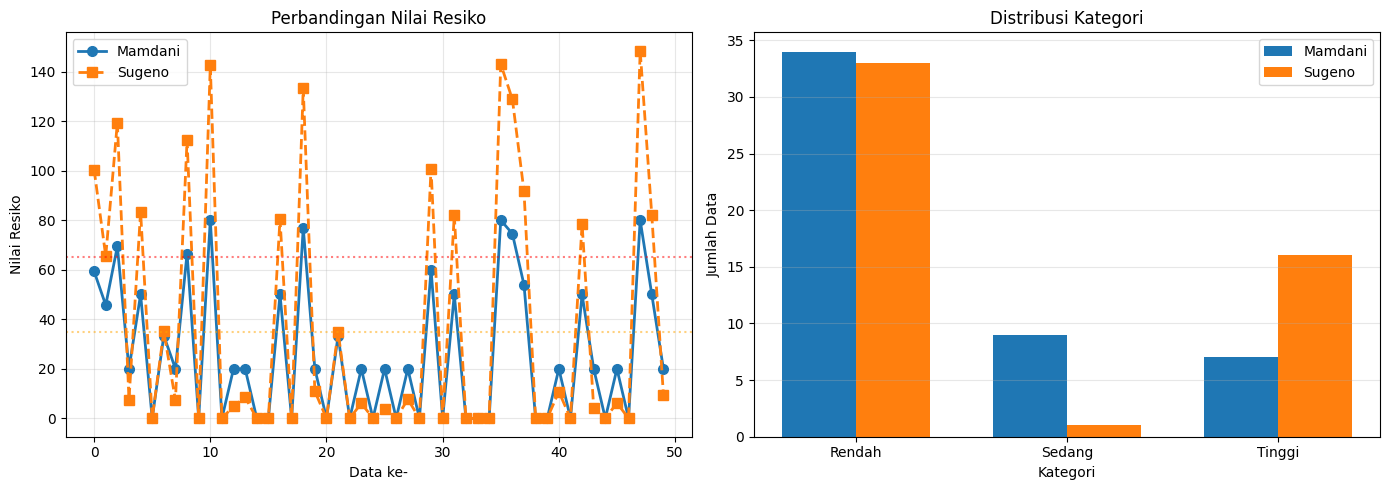

In [10]:
# bikin visualisasi biar keliatan perbedaannya
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# plot perbandingan nilai
data_x = range(len(banding))
ax[0].plot(data_x, banding['Resiko Mamdani'], 'o-', label='Mamdani', linewidth=2, markersize=7)
ax[0].plot(data_x, banding['Resiko Sugeno'], 's--', label='Sugeno', linewidth=2, markersize=7)
ax[0].axhline(y=65, color='r', linestyle=':', alpha=0.5)
ax[0].axhline(y=35, color='orange', linestyle=':', alpha=0.5)
ax[0].set_xlabel('Data ke-')
ax[0].set_ylabel('Nilai Resiko')
ax[0].set_title('Perbandingan Nilai Resiko')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# plot distribusi kategori
kat_mamdani = hasil_df['Kategori Resiko'].value_counts().reindex(['Rendah', 'Sedang', 'Tinggi'], fill_value=0)
kat_sugeno = df_sugeno['Kategori'].value_counts().reindex(['Rendah', 'Sedang', 'Tinggi'], fill_value=0)

pos = range(3)
bar_width = 0.35
ax[1].bar([p - bar_width/2 for p in pos], kat_mamdani.values, bar_width, label='Mamdani')
ax[1].bar([p + bar_width/2 for p in pos], kat_sugeno.values, bar_width, label='Sugeno')
ax[1].set_xlabel('Kategori')
ax[1].set_ylabel('Jumlah Data')
ax[1].set_title('Distribusi Kategori')
ax[1].set_xticks(pos)
ax[1].set_xticklabels(['Rendah', 'Sedang', 'Tinggi'])
ax[1].legend()
ax[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Sistem Fuzzy untuk Kelayakan Beasiswa

In [11]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [12]:
# Variabel fuzzy
ipk = ctrl.Antecedent(np.arange(0, 4.1, 0.1), 'ipk')
toefl = ctrl.Antecedent(np.arange(250, 601, 1), 'toefl')
income = ctrl.Antecedent(np.arange(0, 2.1, 0.01), 'income')  # juta
eligibility = ctrl.Consequent(np.arange(0, 101, 1), 'eligibility')

In [13]:
# Fungsi keanggotaan
ipk['cukup'] = fuzz.trimf(ipk.universe, [2.5, 3.0, 3.5])
ipk['bagus'] = fuzz.trimf(ipk.universe, [3.0, 3.5, 4.0])

toefl['menengah'] = fuzz.trimf(toefl.universe, [400, 450, 500])
toefl['tinggi'] = fuzz.trimf(toefl.universe, [500, 550, 600])

income['kecil'] = fuzz.trapmf(income.universe, [0, 0, 0.6, 1.0])
income['sedang'] = fuzz.trimf(income.universe, [0.8, 1.2, 1.6])
income['besar'] = fuzz.trimf(income.universe, [1.4, 1.7, 2.0])
income['sangat_besar'] = fuzz.trapmf(income.universe, [1.8, 2.0, 2.0, 2.0])

eligibility['rendah'] = fuzz.trimf(eligibility.universe, [0, 25, 50])
eligibility['tinggi'] = fuzz.trimf(eligibility.universe, [50, 75, 100])

In [14]:
# Rules
rule1 = ctrl.Rule(ipk['bagus'] & (income['kecil'] | income['sedang']),
                eligibility['tinggi'])

rule2 = ctrl.Rule(ipk['bagus'] & (income['besar'] | income['sangat_besar']),
                eligibility['rendah'])

rule3 = ctrl.Rule(ipk['cukup'] & (income['kecil'] | income['sedang']),
                eligibility['rendah'])

rule4 = ctrl.Rule(toefl['tinggi'] & (income['kecil'] | income['sedang']),
                eligibility['tinggi'])

rule5 = ctrl.Rule(toefl['menengah'] & (income['kecil'] | income['sedang']),
                eligibility['tinggi'])

In [15]:
# Sistem kontrol
system = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
sim = ctrl.ControlSystemSimulation(system)

In [16]:
# Data mahasiswa
students = [
    ('Tyes', 450, 4, 0.75),
    ('Bowo', 480, 3, 1.50),
    ('Erna', 360, 3, 1.26),
    ('Astuti', 270, 2, 1.04),
    ('Yuni', 420, 4, 0.95),
    ('Heribertus', 390, 4, 1.60),
    ('Edy', 370, 3, 1.25),
    ('Usman', 255, 3, 0.55),
    ('Pujiono', 325, 2, 0.74),
    ('Slamet', 250, 1, 0.86)
]

In [17]:
# Hitung kelayakan beasiswa
hasil_beasiswa = []

for name, t, i, inc in students:
    sim.input['toefl'] = t
    sim.input['ipk'] = i
    sim.input['income'] = inc
    
    try:
        sim.compute()
        nilai = sim.output['eligibility']
        
        # Kategorisasi eligibility
        if nilai >= 50:
            kategori = 'Tinggi'
        else:
            kategori = 'Rendah'
        
        print(f"{name:10s} → Nilai Kelayakan: {nilai:.2f} ({kategori})")
        hasil_beasiswa.append({'Nama': name, 'TOEFL': t, 'IPK': i, 'Income': inc, 'Kelayakan': nilai, 'Kategori': kategori})
    except KeyError:
        print(f"{name:10s} → Tidak dapat dihitung (tidak memenuhi rule)")
        hasil_beasiswa.append({'Nama': name, 'TOEFL': t, 'IPK': i, 'Income': inc, 'Kelayakan': 'N/A', 'Kategori': 'N/A'})

Tyes       → Nilai Kelayakan: 75.00 (Tinggi)
Bowo       → Nilai Kelayakan: 50.00 (Rendah)
Erna       → Nilai Kelayakan: 25.00 (Rendah)
Astuti     → Tidak dapat dihitung (tidak memenuhi rule)
Yuni       → Nilai Kelayakan: 75.00 (Tinggi)
Heribertus → Tidak dapat dihitung (tidak memenuhi rule)
Edy        → Nilai Kelayakan: 25.00 (Rendah)
Usman      → Nilai Kelayakan: 25.00 (Rendah)
Pujiono    → Tidak dapat dihitung (tidak memenuhi rule)
Slamet     → Tidak dapat dihitung (tidak memenuhi rule)


In [18]:
# Hasil beasiswa dalam DataFrame
df_beasiswa = pd.DataFrame(hasil_beasiswa)
print("\nHasil Penilaian Kelayakan Beasiswa:")
print(df_beasiswa)


Hasil Penilaian Kelayakan Beasiswa:
         Nama  TOEFL  IPK  Income Kelayakan Kategori
0        Tyes    450    4    0.75      75.0   Tinggi
1        Bowo    480    3    1.50      50.0   Rendah
2        Erna    360    3    1.26      25.0   Rendah
3      Astuti    270    2    1.04       N/A      N/A
4        Yuni    420    4    0.95      75.0   Tinggi
5  Heribertus    390    4    1.60       N/A      N/A
6         Edy    370    3    1.25      25.0   Rendah
7       Usman    255    3    0.55      25.0   Rendah
8     Pujiono    325    2    0.74       N/A      N/A
9      Slamet    250    1    0.86       N/A      N/A


# Metode Tsukamoto untuk Beasiswa

In [19]:
# fungsi membership monoton naik (untuk output tinggi)
def membership_naik(alpha, a, b):
    # z = a + alpha * (b - a)
    return a + alpha * (b - a)

# fungsi membership monoton turun (untuk output rendah)
def membership_turun(alpha, a, b):
    # z = b - alpha * (b - a)
    return b - alpha * (b - a)

In [20]:
# implementasi tsukamoto
hasil_tsukamoto = []

for name, toefl_val, ipk_val, income_val in students:
    # hitung derajat keanggotaan input
    # IPK
    if ipk_val <= 2.5:
        mu_ipk_cukup = 0
    elif 2.5 < ipk_val <= 3.0:
        mu_ipk_cukup = (ipk_val - 2.5) / (3.0 - 2.5)
    elif 3.0 < ipk_val <= 3.5:
        mu_ipk_cukup = (3.5 - ipk_val) / (3.5 - 3.0)
    else:
        mu_ipk_cukup = 0
    
    if ipk_val <= 3.0:
        mu_ipk_bagus = 0
    elif 3.0 < ipk_val <= 3.5:
        mu_ipk_bagus = (ipk_val - 3.0) / (3.5 - 3.0)
    elif 3.5 < ipk_val <= 4.0:
        mu_ipk_bagus = (4.0 - ipk_val) / (4.0 - 3.5)
    else:
        mu_ipk_bagus = 0
    
    # TOEFL
    if toefl_val <= 400:
        mu_toefl_menengah = 0
    elif 400 < toefl_val <= 450:
        mu_toefl_menengah = (toefl_val - 400) / (450 - 400)
    elif 450 < toefl_val <= 500:
        mu_toefl_menengah = (500 - toefl_val) / (500 - 450)
    else:
        mu_toefl_menengah = 0
    
    if toefl_val <= 500:
        mu_toefl_tinggi = 0
    elif 500 < toefl_val <= 550:
        mu_toefl_tinggi = (toefl_val - 500) / (550 - 500)
    elif 550 < toefl_val <= 600:
        mu_toefl_tinggi = (600 - toefl_val) / (600 - 550)
    else:
        mu_toefl_tinggi = 0
    
    # Income
    if income_val <= 0.6:
        mu_income_kecil = 1
    elif 0.6 < income_val <= 1.0:
        mu_income_kecil = (1.0 - income_val) / (1.0 - 0.6)
    else:
        mu_income_kecil = 0
    
    if income_val <= 0.8:
        mu_income_sedang = 0
    elif 0.8 < income_val <= 1.2:
        mu_income_sedang = (income_val - 0.8) / (1.2 - 0.8)
    elif 1.2 < income_val <= 1.6:
        mu_income_sedang = (1.6 - income_val) / (1.6 - 1.2)
    else:
        mu_income_sedang = 0
    
    # evaluasi rule tsukamoto
    rules_z = []
    rules_alpha = []
    
    # rule 1: IPK bagus AND (income kecil OR sedang) -> tinggi
    alpha1 = min(mu_ipk_bagus, max(mu_income_kecil, mu_income_sedang))
    if alpha1 > 0:
        z1 = membership_naik(alpha1, 50, 100)  # output tinggi (monoton naik dari 50 ke 100)
        rules_z.append(z1)
        rules_alpha.append(alpha1)
    
    # rule 2: TOEFL tinggi AND (income kecil OR sedang) -> tinggi
    alpha2 = min(mu_toefl_tinggi, max(mu_income_kecil, mu_income_sedang))
    if alpha2 > 0:
        z2 = membership_naik(alpha2, 50, 100)
        rules_z.append(z2)
        rules_alpha.append(alpha2)
    
    # rule 3: TOEFL menengah AND (income kecil OR sedang) -> tinggi
    alpha3 = min(mu_toefl_menengah, max(mu_income_kecil, mu_income_sedang))
    if alpha3 > 0:
        z3 = membership_naik(alpha3, 50, 100)
        rules_z.append(z3)
        rules_alpha.append(alpha3)
    
    # rule 4: IPK cukup AND (income kecil OR sedang) -> rendah
    alpha4 = min(mu_ipk_cukup, max(mu_income_kecil, mu_income_sedang))
    if alpha4 > 0:
        z4 = membership_turun(alpha4, 0, 50)  # output rendah (monoton turun dari 50 ke 0)
        rules_z.append(z4)
        rules_alpha.append(alpha4)
    
    # defuzzifikasi weighted average
    if sum(rules_alpha) > 0:
        z_akhir = sum([z * a for z, a in zip(rules_z, rules_alpha)]) / sum(rules_alpha)
    else:
        z_akhir = 0
    
    hasil_tsukamoto.append({
        'Nama': name,
        'TOEFL': toefl_val,
        'IPK': ipk_val,
        'Income': income_val,
        'Kelayakan Tsukamoto': z_akhir
    })

df_tsukamoto = pd.DataFrame(hasil_tsukamoto)
print("\nHasil Metode Tsukamoto:")
print(df_tsukamoto.to_string(index=False))


Hasil Metode Tsukamoto:
      Nama  TOEFL  IPK  Income  Kelayakan Tsukamoto
      Tyes    450    4    0.75                81.25
      Bowo    480    3    1.50                50.00
      Erna    360    3    1.26                 7.50
    Astuti    270    2    1.04                 0.00
      Yuni    420    4    0.95                68.75
Heribertus    390    4    1.60                 0.00
       Edy    370    3    1.25                 6.25
     Usman    255    3    0.55                 0.00
   Pujiono    325    2    0.74                 0.00
    Slamet    250    1    0.86                 0.00


In [21]:
# bandingin Mamdani vs Tsukamoto
# cuma ambil yang valid di Mamdani
df_beasiswa_clean = df_beasiswa[df_beasiswa['Kelayakan'] != 'N/A'].copy()
df_beasiswa_clean['Kelayakan'] = df_beasiswa_clean['Kelayakan'].astype(float)

# filter tsukamoto sesuai nama yang valid di mamdani
nama_valid = df_beasiswa_clean['Nama'].tolist()
df_tsukamoto_valid = df_tsukamoto[df_tsukamoto['Nama'].isin(nama_valid)].copy()

perbandingan_beasiswa = pd.DataFrame({
    'Nama': df_tsukamoto_valid['Nama'].values,
    'TOEFL': df_tsukamoto_valid['TOEFL'].values,
    'IPK': df_tsukamoto_valid['IPK'].values,
    'Income': df_tsukamoto_valid['Income'].values,
    'Mamdani': df_beasiswa_clean['Kelayakan'].values,
    'Tsukamoto': df_tsukamoto_valid['Kelayakan Tsukamoto'].values
})

perbandingan_beasiswa['Selisih'] = abs(perbandingan_beasiswa['Mamdani'] - perbandingan_beasiswa['Tsukamoto'])

print("\nPerbandingan Mamdani vs Tsukamoto:")
print(perbandingan_beasiswa.to_string(index=False))
print(f"\nSelisih rata-rata: {perbandingan_beasiswa['Selisih'].mean():.2f}")
print(f"Selisih terbesar: {perbandingan_beasiswa['Selisih'].max():.2f}")


Perbandingan Mamdani vs Tsukamoto:
 Nama  TOEFL  IPK  Income  Mamdani  Tsukamoto      Selisih
 Tyes    450    4    0.75     75.0      81.25 6.250000e+00
 Bowo    480    3    1.50     50.0      50.00 7.105427e-15
 Erna    360    3    1.26     25.0       7.50 1.750000e+01
 Yuni    420    4    0.95     75.0      68.75 6.250000e+00
  Edy    370    3    1.25     25.0       6.25 1.875000e+01
Usman    255    3    0.55     25.0       0.00 2.500000e+01

Selisih rata-rata: 12.29
Selisih terbesar: 25.00


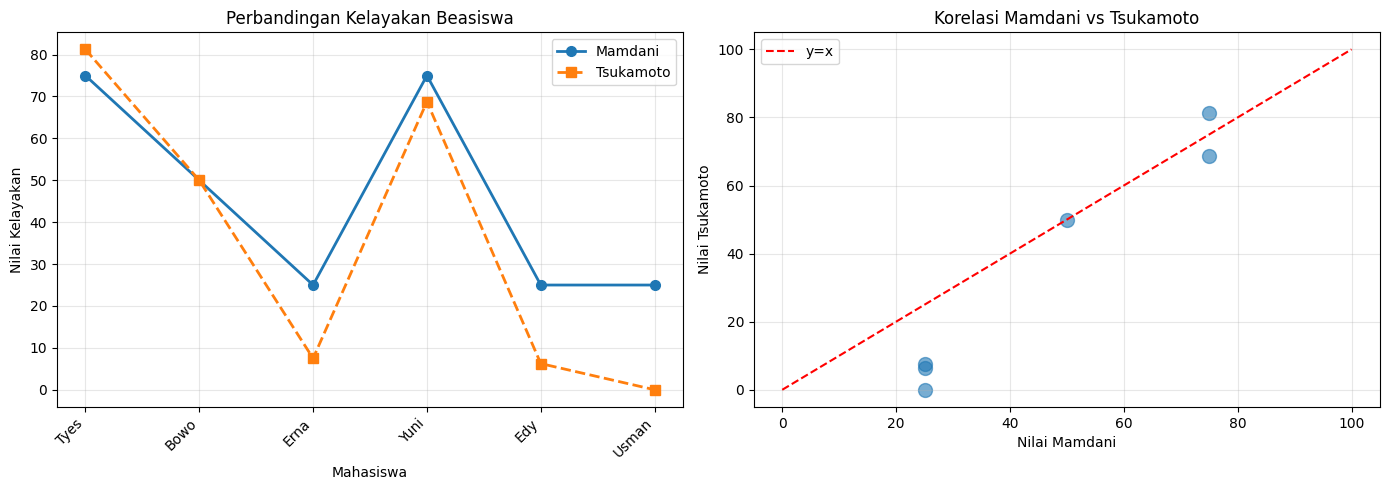

In [22]:
# visualisasi perbandingan beasiswa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot perbandingan per mahasiswa
x_mhs = range(len(perbandingan_beasiswa))
axes[0].plot(x_mhs, perbandingan_beasiswa['Mamdani'], 'o-', label='Mamdani', linewidth=2, markersize=7)
axes[0].plot(x_mhs, perbandingan_beasiswa['Tsukamoto'], 's--', label='Tsukamoto', linewidth=2, markersize=7)
axes[0].set_xlabel('Mahasiswa')
axes[0].set_ylabel('Nilai Kelayakan')
axes[0].set_title('Perbandingan Kelayakan Beasiswa')
axes[0].set_xticks(x_mhs)
axes[0].set_xticklabels(perbandingan_beasiswa['Nama'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot scatter mamdani vs tsukamoto
axes[1].scatter(perbandingan_beasiswa['Mamdani'], perbandingan_beasiswa['Tsukamoto'], s=100, alpha=0.6)
axes[1].plot([0, 100], [0, 100], 'r--', label='y=x')
axes[1].set_xlabel('Nilai Mamdani')
axes[1].set_ylabel('Nilai Tsukamoto')
axes[1].set_title('Korelasi Mamdani vs Tsukamoto')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()